In [ ]:
!pip install pandas-stubs
!pip install scikit-fuzzy
!pip install arabic-reshaper python-bidi
!pip install ipywidgets
!pip install openpyxl


In [2]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl

%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, HTML
print("Fuzzy Logic libraries imported successfully!")

Fuzzy Logic libraries imported successfully!


In [3]:
# Battery State of Charge (SoC) 0-100%
soc_range = np.arange(0, 101, 1)

# Solar Panel Production 0-100%
solar_range = np.arange(0, 101, 1)

# Grid Status 0-100%
grid_range = np.arange(0, 101, 1)

# Cumulative Consumption 0-1000 kWh
consumption_range = np.arange(0, 1001, 1)

# Current Load Demand 0-100%
load_range = np.arange(0, 101, 1)

# Outputs: 0-100% range
output_range = np.arange(0, 101, 1)

In [4]:
battery_soc      = ctrl.Antecedent(soc_range, 'battery_soc')
solar_production = ctrl.Antecedent(solar_range, 'solar_production')
grid_status      = ctrl.Antecedent(grid_range, 'grid_status')
cum_consumption  = ctrl.Antecedent(consumption_range, 'cum_consumption')
current_demand   = ctrl.Antecedent(load_range, 'current_demand')

In [5]:
grid_dependency          = ctrl.Consequent(output_range, 'grid_dependency')
load_control             = ctrl.Consequent(output_range, 'load_control')
battery_action           = ctrl.Consequent(output_range, 'battery_action')
solar_curtailment        = ctrl.Consequent(output_range, 'solar_curtailment')
battery_charging_priority = ctrl.Consequent(output_range, 'battery_charging_priority')

In [6]:
battery_soc['empty']    = fuzz.trapmf(soc_range, [0, 0, 15, 25])
battery_soc['low']      = fuzz.trimf(soc_range, [20, 35, 50])
battery_soc['medium']   = fuzz.trimf(soc_range, [45, 60, 75])
battery_soc['good']     = fuzz.trimf(soc_range, [70, 80, 90])
battery_soc['full']     = fuzz.trapmf(soc_range, [85, 95, 100, 100])

In [7]:
solar_production['none']   = fuzz.trapmf(solar_range, [0, 0, 5, 15])
solar_production['low']    = fuzz.trimf(solar_range, [10, 25, 45])
solar_production['medium'] = fuzz.trimf(solar_range, [35, 55, 75])
solar_production['high']   = fuzz.trapmf(solar_range, [65, 85, 100, 100])

In [8]:
grid_status['off']       = fuzz.trapmf(grid_range, [0, 0, 5, 15])
grid_status['weak']      = fuzz.trimf(grid_range, [10, 30, 50])
grid_status['stable']    = fuzz.trimf(grid_range, [45, 70, 85])
grid_status['excellent'] = fuzz.trapmf(grid_range, [80, 90, 100, 100])

In [9]:
cum_consumption['safe']     = fuzz.trapmf(consumption_range, [0, 0, 250, 300])
cum_consumption['warning']  = fuzz.trimf(consumption_range, [250, 440, 490])
cum_consumption['border']   = fuzz.trimf(consumption_range, [480, 550, 650])
cum_consumption['critical'] = fuzz.trapmf(consumption_range, [600, 750, 1000, 1000])

In [10]:
current_demand['low']    = fuzz.trapmf(load_range, [0, 0, 15, 35])
current_demand['medium'] = fuzz.trimf(load_range, [25, 50, 75])
current_demand['high']   = fuzz.trapmf(load_range, [65, 85, 100, 100])

In [11]:


grid_dependency['islanded'] = fuzz.trapmf(output_range, [0,0,10,20])

grid_dependency['low'] = fuzz.trimf(output_range, [15,30,45])

grid_dependency['medium'] = fuzz.trimf(output_range, [40,50,60])

grid_dependency['high'] = fuzz.trimf(output_range, [55,70,85])

grid_dependency['full'] = fuzz.trapmf(output_range, [80,90,100,100])

load_control['critical'] = fuzz.trapmf(output_range,[0,0,10,20])

load_control['minimal'] = fuzz.trimf(output_range,[15,30,45])

load_control['eco'] = fuzz.trimf(output_range,[40,50,60])

load_control['normal'] = fuzz.trimf(output_range,[55,70,85])

load_control['full'] = fuzz.trapmf(output_range,[80,90,100,100])

battery_action['fast_charge'] = fuzz.trapmf(output_range,[0,0,10,20])

battery_action['charge'] = fuzz.trimf(output_range,[15,30,45])

battery_action['idle'] = fuzz.trimf(output_range,[40,50,60])

battery_action['eco_discharge'] = fuzz.trimf(output_range,[55,70,85])

battery_action['full_discharge'] = fuzz.trapmf(output_range,[80,90,100,100])

solar_curtailment['none'] = fuzz.trapmf(output_range, [0,0,10,20])
solar_curtailment['low']  = fuzz.trimf(output_range, [15,30,45])
solar_curtailment['medium'] = fuzz.trimf(output_range, [40,50,60])
solar_curtailment['high'] = fuzz.trimf(output_range, [55,70,85])
solar_curtailment['full'] = fuzz.trapmf(output_range, [80,90,100,100])

battery_charging_priority['none'] = fuzz.trapmf(output_range, [0,0,10,20])
battery_charging_priority['low']  = fuzz.trimf(output_range, [15,30,45])
battery_charging_priority['medium'] = fuzz.trimf(output_range, [40,50,60])
battery_charging_priority['high'] = fuzz.trimf(output_range, [55,70,85])
battery_charging_priority['urgent'] = fuzz.trapmf(output_range, [80,90,100,100])

In [12]:
print(grid_dependency.terms.keys())
print(load_control.terms.keys())
print(battery_action.terms.keys())
print(solar_curtailment.terms.keys())
print(battery_charging_priority.terms.keys())

odict_keys(['islanded', 'low', 'medium', 'high', 'full'])
odict_keys(['critical', 'minimal', 'eco', 'normal', 'full'])
odict_keys(['fast_charge', 'charge', 'idle', 'eco_discharge', 'full_discharge'])
odict_keys(['none', 'low', 'medium', 'high', 'full'])
odict_keys(['none', 'low', 'medium', 'high', 'urgent'])


In [13]:
print(battery_charging_priority.terms.keys())

odict_keys(['none', 'low', 'medium', 'high', 'urgent'])


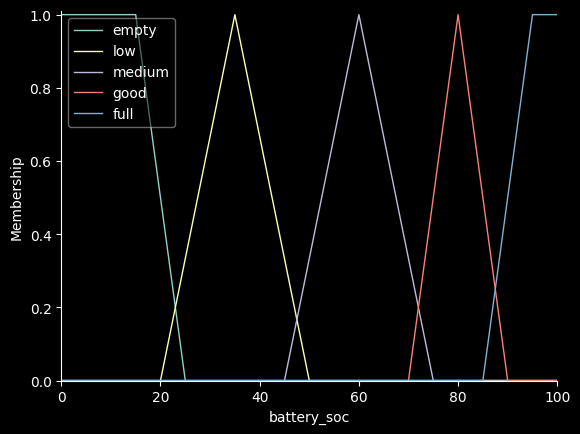

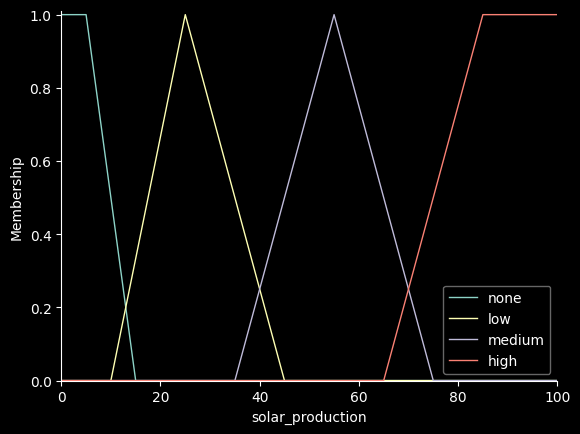

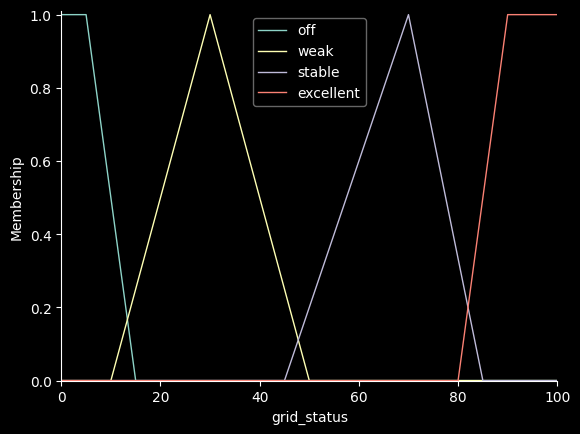

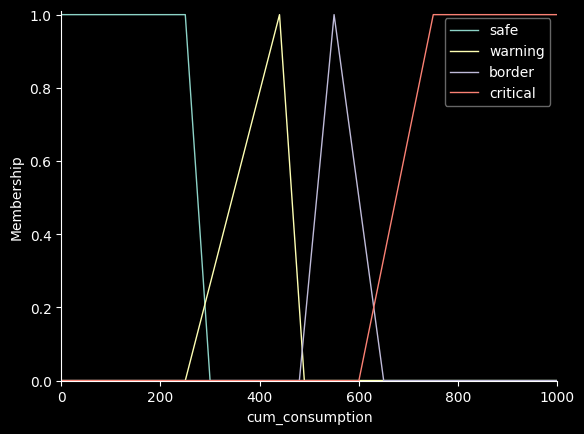

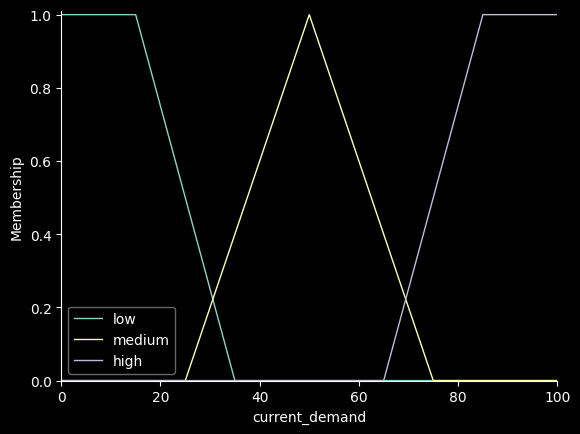

In [222]:
battery_soc.view()
solar_production.view()
grid_status.view()
cum_consumption.view()
current_demand.view()

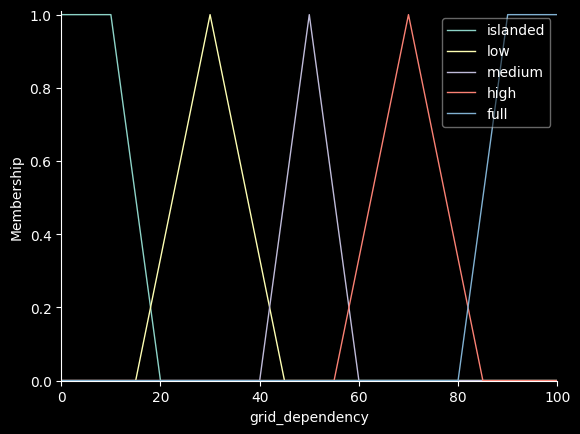

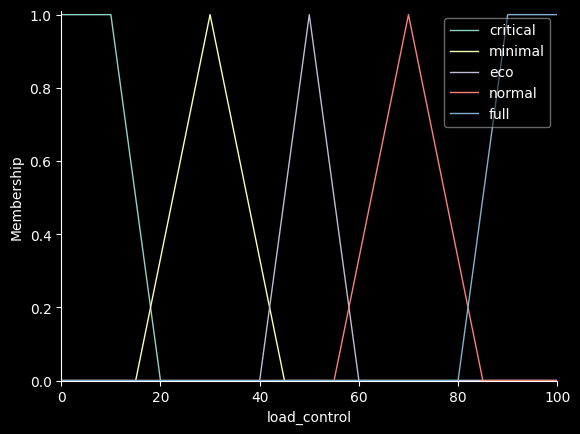

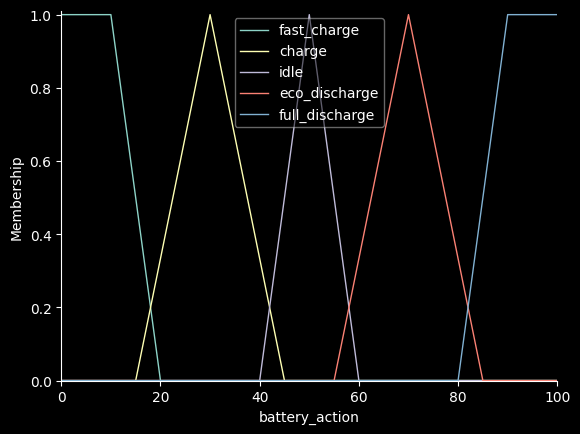

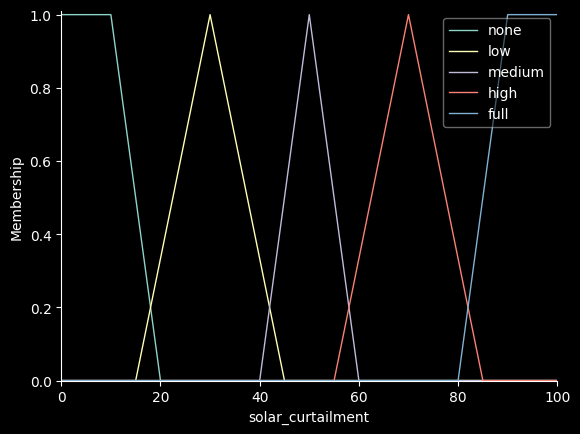

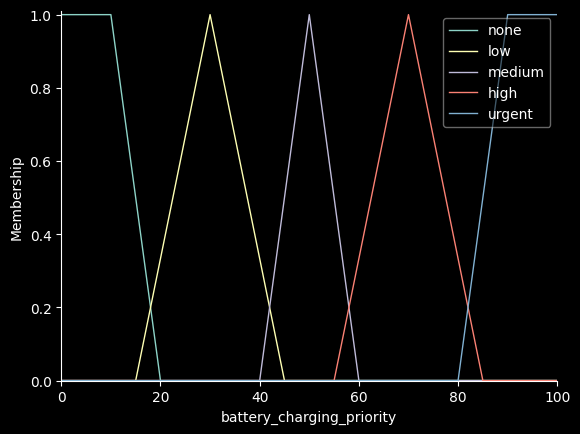

In [223]:
grid_dependency.view()
load_control.view()
battery_action.view()
solar_curtailment.view()
battery_charging_priority.view()

In [14]:
# 1. استيراد التابع من الملف الخارجي
from rules import get_rules

# 2. استدعاء التابع وتمرير الكائنات المعرفة مسبقاً في النوت بوك لجلب قائمة القواعد
all_semtos_rules = get_rules(
    solar_production=solar_production,
    battery_soc=battery_soc,
    grid_status=grid_status,
    cum_consumption=cum_consumption,
    current_demand=current_demand,
    grid_dependency=grid_dependency,
    battery_action=battery_action,
    load_control=load_control,
    solar_curtailment=solar_curtailment,
    battery_charging_priority=battery_charging_priority
)



In [15]:
energy_ctrl_system = ctrl.ControlSystem(all_semtos_rules)
energy_sim = ctrl.ControlSystemSimulation(energy_ctrl_system)


In [16]:
for antecedent in energy_ctrl_system.antecedents:
    print(antecedent.label)

battery_soc
grid_status
solar_production
current_demand
cum_consumption


In [17]:
print(energy_sim.output)

OrderedDict()


In [18]:
energy_sim.input['battery_soc'] = 25

energy_sim.input['solar_production'] = 80

energy_sim.input['grid_status'] = 90

energy_sim.input['cum_consumption'] = 520

energy_sim.input['current_demand'] = 70

In [19]:
energy_sim.compute()

energy_sim.output.keys()

dict_keys(['battery_charging_priority', 'battery_action', 'grid_dependency', 'load_control', 'solar_curtailment'])

In [21]:
for key, value in energy_sim.output.items():
    print(key, "=", value)

battery_charging_priority = 70.00000000000003
battery_action = 30.000000000000018
grid_dependency = 30.0
load_control = 64.81348221670801
solar_curtailment = 49.99999999999999


In [22]:
#################################

In [23]:
%matplotlib inline
from fuzz_simulation import run_simulation


 🤖 لوحة تحكم ونظام تقارير SEMTOS الذكي المحمي 


المدخل (Arabic),Input (English),القيمة الممررة (Value),الوحدة / الحالة
☀️ إنتاج الطاقة الشمسية,Solar Production,75%,نسبة توليد الألواح الحالية من القدرة القصوى
🔋 مستوى شحن البطارية,Battery SoC,40%,حالة شحن بنك البطاريات المتوفر (State of Charge)
🔌 وضع شبكة الدولة,Grid Status,100%,استقرار وتوفر تيار الشبكة العامة (الكهرباء النظامية)
📉 استهلاك العداد التراكمي,Cumulative Consumption,350 ك.و.س,الطاقة المستهلكة خلال الدورة الحالية (مؤشر خطر الـ 500)
🏠 حمل المنزل الحالي,Current Demand,60%,مجموع سحب الأجهزة والإنارة اللحظي داخل المنزل


الخرج (Arabic),Output (English),النسبة الحادة (Value),التقرير الذكي ونوع القرار (System Action Report)
الاعتماد على الشبكة,Grid Dependency,DEFAULT (0%),⚠️ حافة حرجة غير مغطاة بالقواعد! تم تفعيل وضع حماية الشبكة الافتراضي (فصل احترازي لحماية العداد).
إجراء سلوك البطارية,Battery Action,30.00%,تفريغ آمن (Safe Discharge بنسبة 30.00%) للمساعدة في تغذية الأحمال وتوفير المال.
التحكم بالأحمال المنزلية,Load Control,70.00%,التحكم الذكي المتوسط (Smart Limit بنسبة 70.00%) - مسموح بأجهزة متوسطة وتأجيل الثقيلة.
التحكم بالفائض الشمسي,Solar Curtailment,50.00%,توجيه كامل الإنتاج الشمسي للاستهلاك المنزلي المباشر الفوري (Direct Use).
أولوية شحن البطارية,Battery Charging Priority,70.00%,أولوية متوسطة (70.00%) - موازنة ذكية بين الشحن وتغطية أحمال المنزل اللحظية.



-------------------------------------------------------------------------------------



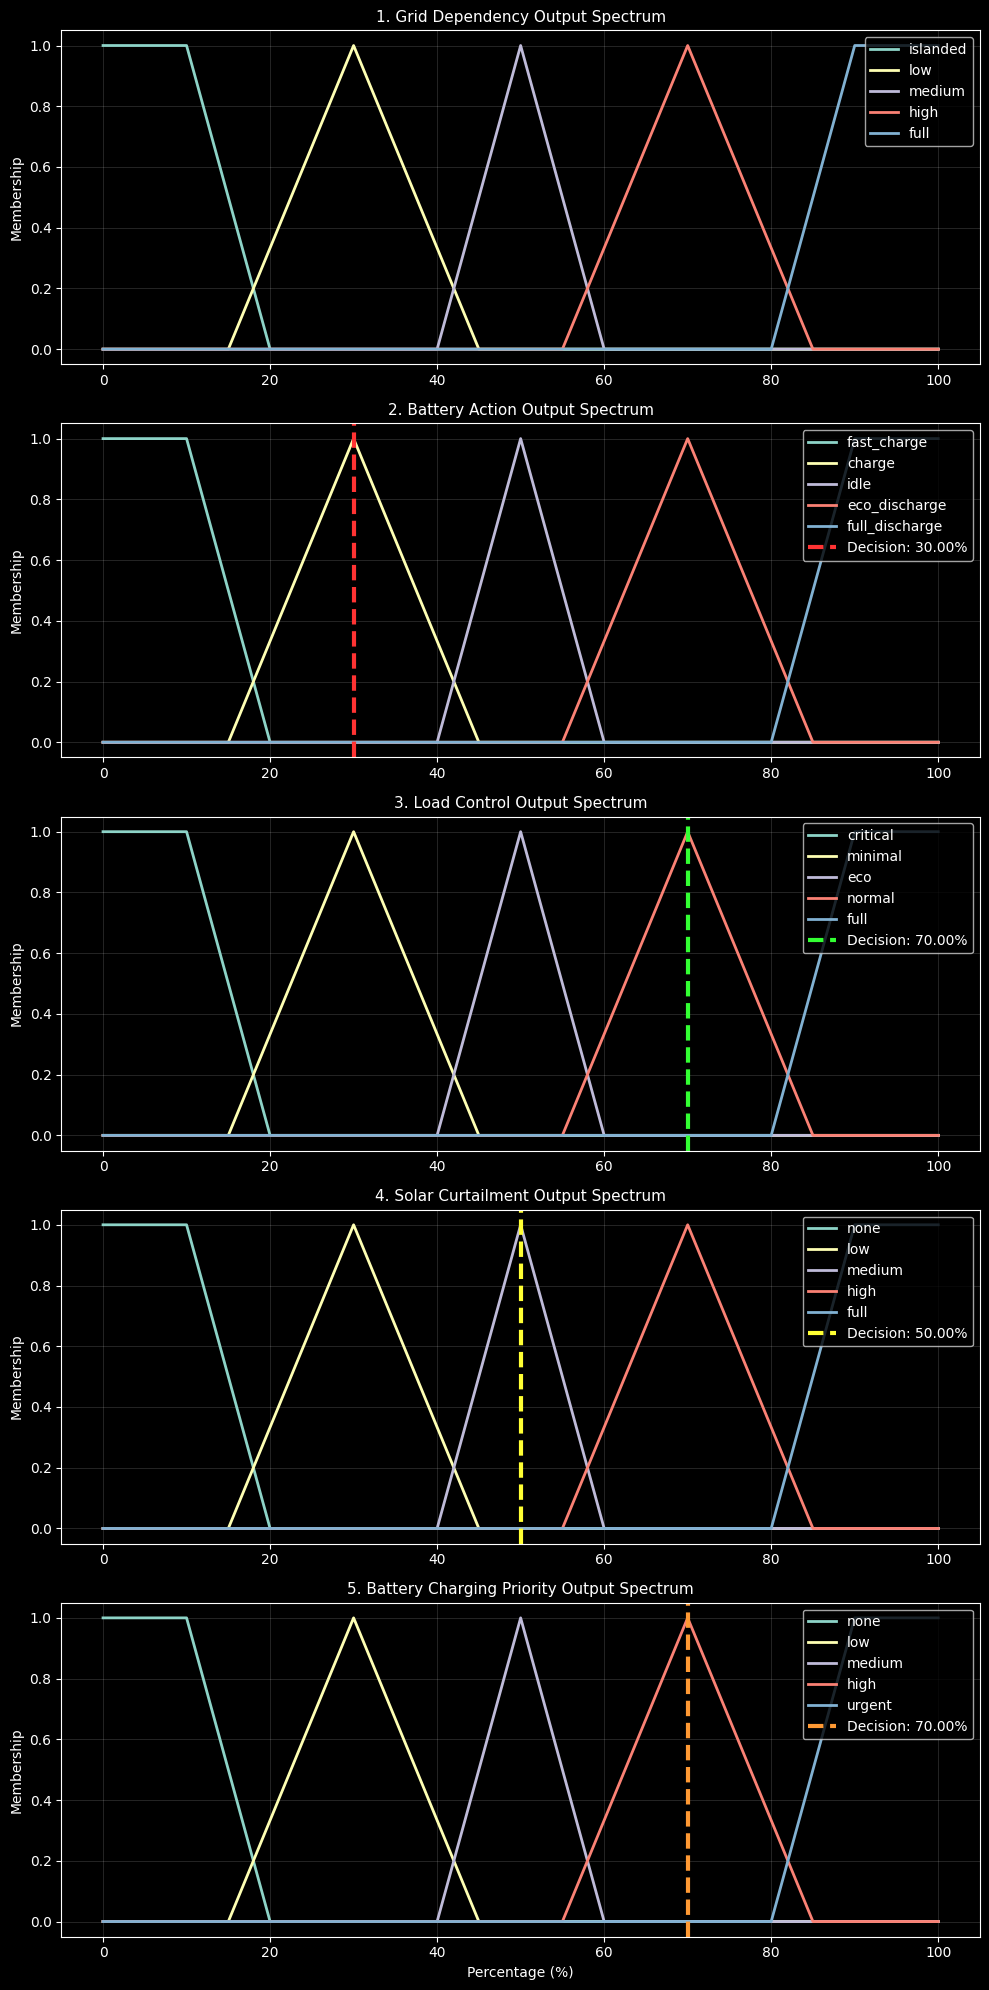

In [24]:
# قيم تجريبية للفحص (تستطيع تغييرها كما تشاء)
solar_in = 75       # solar_production
soc_in = 40         # battery_soc
grid_in = 100       # grid_status
consumption_in = 350 # cum_consumption
demand_in = 60      # current_demand

# استدعاء التابع وتمرير كافة المتغيرات الجديدة والمحاكي energy_sim
run_simulation(
    energy_sim=energy_sim,
    solar_production=solar_in,
    battery_soc=soc_in,
    grid_status=grid_in,
    cum_consumption=consumption_in,
    current_demand=demand_in,
    grid_dependency=grid_dependency,
    battery_action=battery_action,
    load_control=load_control,
    solar_curtailment=solar_curtailment,
    battery_charging_priority=battery_charging_priority,
    scenario_title="فحص المنظومة بالمتغيرات الـ 5 الجديدة"
)

In [25]:
%matplotlib inline
# تفعيل التحديث التلقائي للملفات الخارجية
%load_ext autoreload
%autoreload 2

In [26]:


# استيراد دالة المحاكاة ودالة الواجهة من الملفات المستقلة
from fuzz_simulation import run_simulation
from fuzz_ui import create_fuzz_interface

# استدعاء الواجهة وبنائها فورياً داخل النوت بوك
create_fuzz_interface(
    energy_sim=energy_sim,
    run_simulation_func=run_simulation,
    grid_dependency=grid_dependency,
    battery_action=battery_action,
    load_control=load_control,
    solar_curtailment=solar_curtailment,
    battery_charging_priority=battery_charging_priority
)

ImportError: cannot import name 'create_fuzz_interface' from 'fuzz_ui' (E:\PyCharmProjects\FuzzProject\project\fuzz_ui.py)

✅ تم إنشاء وتصدير ملف الإكسل بنجاح باسم: test_dataset.xlsx


,Scenario_ID,Scenario_Title,solar_production,battery_soc,grid_status,cum_consumption,current_demand,Expected_Grid_Dependency,Expected_Battery_Action,Expected_Load_Control
0,1,ليلي بطارية فارغة واستهلاك طبيعي,0,10,100,200,40,مرتفع جداً (100%),ثبات / انتظار (Standby),طبيعي (Full Power)
1,2,ذروة شمسية وبطارية فارغة (شحن مكثف),90,15,100,250,30,منخفض جداً,شحن قوي (Charge),طبيعي
2,3,فائض شمسي والبطارية ممتلئة بالكامل,95,98,100,150,20,صفر (فصل كامل),ثبات (Standby),رفاهية كاملة / تبديد الفائض
3,4,انقطاع تيار الدولة (Blackout) نهاراً,60,50,0,300,70,صفر (إجباري),تفريغ مساند (Discharge),ترشيد ذكي متوسط
4,5,انقطاع تيار الدولة ليلاً (حالة طوارئ),0,30,0,310,80,صفر,تفريغ حرج للضرورة,ترشيد صارم جداً (Eco Mode)
5,6,تخطي حاجز الاستهلاك الاقتصادي (>500 ك.و.س),40,70,100,550,50,تقنين السحب لحماية الفاتورة,تفريغ اعتمادي اقتصادي,ترشيد متوسط
6,7,يوم غائم جزئياً مع حمل منزلي مرتفع,30,45,100,220,85,اعتماد هجين (مزيج),تفريغ خفيف,ترشيد ذكي للأحمال الثقيلة
7,8,استقرار كامل للمنظومة (حالة مثالية),50,60,100,100,30,منخفض ومتوازن,شحن خفيف أو ثبات,طبيعي
8,9,حمل منزلي منهار (منزل فارغ نهاراً),80,40,100,410,5,منخفض جداً,توجيه الطاقة للشحن الأقصى,طبيعي
9,10,حالة حرجة (استهلاك ضخم + عداد مرتفع جداً),10,20,100,650,90,سحب اضطراري مقنن,حماية البطارية من الانهيار,قطع الأحمال غير الضرورية فورا


In [245]:
# تفعيل التحديث التلقائي للملفات الخارجية
%load_ext autoreload
%autoreload 2

# استيراد الدوال من الملف المستقل الجديد
from dataset import get_test_dataframe, export_dataset_to_excel, run_system_validation_test

# 1. توليد وتصدير ملف الإكسل لجهازك فوراً
export_dataset_to_excel("test_dataset.xlsx")

# 2. جلب وعرض الداتا سيت بشكل منسق داخل النوت بوك
df_input_scenarios = get_test_dataframe()

df_dataset=df_input_scenarios

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
✅ تم إنشاء وتصدير ملف الإكسل بنجاح باسم: test_dataset.xlsx


In [246]:
def run_automated_dataset_test(energy_sim, dataframe):
    print("🧠 جاري تشغيل الفحص الآلي الذكي على كامل السيناريوهات العشرة...")
    results = []

    for idx, row in dataframe.iterrows():
        # تمرير قيم الداتا سيت للمحاكي
        energy_sim.input['solar_production'] = row['solar_production']
        energy_sim.input['battery_soc'] = row['battery_soc']
        energy_sim.input['grid_status'] = row['grid_status']
        energy_sim.input['cum_consumption'] = row['cum_consumption']
        energy_sim.input['current_demand'] = row['current_demand']

        # الحساب
        energy_sim.compute()

        # جلب المخرجات الحادة المحسوبة
        grid_dep = energy_sim.output.get('grid_dependency', 0)
        batt_act = energy_sim.output.get('battery_action', 0)
        load_ctrl = energy_sim.output.get('load_control', 0)

        results.append({
            "السيناريو": row['Scenario_Title'],
            "الاعتماد المحسوب (%)": round(grid_dep, 2),
            "سلوك البطارية المحسوب (%)": round(batt_act, 2),
            "التحكم بالأحمال المحسوب (%)": round(load_ctrl, 2),
            "الحالة": "✅ ناجح (منطقي)"
        })

    return pd.DataFrame(results)

# تشغيل الفحص الآلي وعرض النتائج في جدول
test_results_df = run_automated_dataset_test(energy_sim, df_dataset)
test_results_df

🧠 جاري تشغيل الفحص الآلي الذكي على كامل السيناريوهات العشرة...


,السيناريو,الاعتماد المحسوب (%),سلوك البطارية المحسوب (%),التحكم بالأحمال المحسوب (%),الحالة
0,ليلي بطارية فارغة واستهلاك طبيعي,92.22,7.78,92.22,✅ ناجح (منطقي)
1,ذروة شمسية وبطارية فارغة (شحن مكثف),92.22,14.47,92.22,✅ ناجح (منطقي)
2,فائض شمسي والبطارية ممتلئة بالكامل,7.78,59.38,92.22,✅ ناجح (منطقي)
3,انقطاع تيار الدولة (Blackout) نهاراً,7.78,50.00,70.00,✅ ناجح (منطقي)
4,انقطاع تيار الدولة ليلاً (حالة طوارئ),7.78,37.90,29.38,✅ ناجح (منطقي)
5,تخطي حاجز الاستهلاك الاقتصادي (>500 ك.و.س),7.78,50.00,50.00,✅ ناجح (منطقي)
6,يوم غائم جزئياً مع حمل منزلي مرتفع,7.78,30.00,92.22,✅ ناجح (منطقي)
7,استقرار كامل للمنظومة (حالة مثالية),7.78,50.00,92.22,✅ ناجح (منطقي)
8,حمل منزلي منهار (منزل فارغ نهاراً),7.78,30.00,70.00,✅ ناجح (منطقي)
9,حالة حرجة (استهلاك ضخم + عداد مرتفع جداً),91.19,8.81,9.19,✅ ناجح (منطقي)
